# Kraus operators from HEOM — the non-Markovian dynamical map from the hierarchy

**Goal.** Extract a set of Kraus operators $\{M_k(t)\}$ directly from the **Hierarchical Equations
of Motion (HEOM)**, feed them into the same grid pipeline used for the path-integral map
(`grid_pipeline.py`: $\mathcal{L}(t)\to$ Choi $\to$ Kraus $\to$ operator sum), and verify that the
resulting non-unitary dynamics reproduces a **standard HEOM run** to numerical precision.

**The idea (qHEOM, Batista et al., *JCTC* 2025, arXiv:2411.12049).** HEOM can be written as a
*Schrödinger-like* equation on an extended space (system $\otimes$ auxiliary density operators, ADOs):
$\tfrac{d}{dt}|\Psi\rangle=\hat{\mathcal L}_{\rm HEOM}|\Psi\rangle$. The **reduced dynamical map** of the
open system is the top-left (physical / zeroth-ADO) block of the extended propagator,
$$G(t)=\mathcal{P}\,e^{\hat{\mathcal L}_{\rm HEOM}\,t}\,\mathcal{P}^\dagger \quad(\text{their Eq. 33}),$$
with the ADOs initialised to **zero** ($\mathcal{P}^\dagger|\Psi(0)\rangle=|\Psi(0)\rangle$).
$G(t)$ is a $d^2\times d^2$ matrix — exactly the object our grid pipeline turns into Kraus operators.

**Why this gives the *full* dynamics (the ADO subtlety).** The physical reduced state is
$\rho_S(t)=\mathrm{tr}_B[U(t)\,\rho_S(0)\otimes\rho_B^{\rm eq}\,U^\dagger(t)]$. In HEOM this is *exactly*
the zeroth ADO $\rho_{\mathbf 0}(t)$, with the factorised initial condition
$\rho_{\mathbf 0}(0)=\rho_S(0)$, $\rho_{\mathbf n\neq\mathbf 0}(0)=0$. The higher ADOs are **not
discarded** — they are fully propagated (they carry the bath memory / non-Markovianity); we merely
start them at zero and read out $\rho_{\mathbf 0}$. So the map $\rho_S(0)\mapsto\rho_{\mathbf 0}(t)$
built with zero-ADO initial conditions **is** the exact reduced CPTP map $\mathcal E_{t,0}$.

**References**
1. A. Seneviratne, P. L. Walters, F. Wang, *ACS Omega* **9**, 9666 (2024) — the Kraus / SVD-dilation pipeline we reuse.
2. Y. Wang, X. Li, ... V. S. Batista, *J. Chem. Theory Comput.* **21**, 1530 (2025); arXiv:2411.12049 — qHEOM: the projected HEOM propagator $G(t)=\mathcal P e^{\hat{\mathcal L}t}\mathcal P^\dagger$.
3. Y. Tanimura, *J. Chem. Phys.* **153**, 020901 (2020) — HEOM review.
4. H.-B. Chen *et al.*, *New J. Phys.* **19**, 013007 (2017) — complete positivity within HEOM (truncation can break CP).
5. A. Ishizaki, G. R. Fleming, *PNAS* **106**, 17255 (2009) — FMO Drude bath parameters.


## 1. Theory: from the hierarchy to a $d^2\times d^2$ map

### 1.1 HEOM as a linear flow on the extended space

For Drude baths the reservoir correlation function is a sum of exponentials,
$C(t)=\sum_m d_m e^{-\nu_m t}$, and HEOM replaces the non-local memory by a set of **auxiliary
density operators (ADOs)** $\rho_{\mathbf n}$ labelled by occupation vectors $\mathbf n$ over the
exponential modes. They obey a *linear, time-local, first-order* system

$$\dot\rho_{\mathbf n}=\Big(-i H_S^{\times}-\sum_{j,m}n_{jm}\nu_m\Big)\rho_{\mathbf n}
-i\sum_{j,m}\Big[\,\hat Q_j^{\times}\rho_{\mathbf n^+_{jm}}
+ n_{jm}\big(d_m\hat Q_j\,\rho_{\mathbf n^-_{jm}}-d_m^*\rho_{\mathbf n^-_{jm}}\hat Q_j\big)\Big],$$

with $\hat Q_j=|j\rangle\langle j|$ the system coupling operators. Stacking all ADOs into one big
vector $|\Psi\rangle=\big(\mathrm{vec}\,\rho_{\mathbf 0},\mathrm{vec}\,\rho_{\mathbf n_1},\dots\big)^\top$
this is $\dot{|\Psi\rangle}=\hat{\mathcal L}_{\rm HEOM}|\Psi\rangle$ with a **constant** (non-Hermitian)
generator $\hat{\mathcal L}_{\rm HEOM}$, so $|\Psi(t)\rangle=e^{\hat{\mathcal L}_{\rm HEOM}t}|\Psi(0)\rangle$.

### 1.2 The reduced map = top-left block of the propagator

Order the ADOs so the zeroth ADO (all modes empty, $\mathbf n=\mathbf 0$) sits in block $0$; that block
*is* the reduced density matrix $\rho_S=\rho_{\mathbf 0}$. With the factorised initial condition all
higher ADOs vanish, $|\Psi(0)\rangle=(\,\mathrm{vec}\,\rho_S(0),\,0,\dots)^\top$. Applying the
propagator and reading block $0$ back out,

$$\boxed{\;\mathrm{vec}\,\rho_S(t)=\underbrace{\big[e^{\hat{\mathcal L}_{\rm HEOM}\,t}\big]_{\mathbf 0\mathbf 0}}_{\displaystyle G(t)=\mathcal L(t)}\ \mathrm{vec}\,\rho_S(0),\;}$$

i.e. the reduced map $\mathcal L(t)$ is the **top-left $d^2\times d^2$ block** of the extended matrix
exponential. This is Batista's Eq. 33 with $\mathcal P$ = projector onto the zeroth ADO. Because it
descends from a global unitary + partial trace, $\mathcal E_{t,0}$ is CPTP; the only caveat is that a
**finite ADO truncation** can introduce tiny CP violations (ref. 4) — we monitor this via the minimum
Choi eigenvalue below.

### 1.3 Building the map in practice

Two equivalent routes give the same $\mathcal L(t)$:

* **(A) black-box:** run the HEOM solver $d^2$ times, once per basis operator $E_{ij}=|i\rangle\langle j|$
  as initial system state (ADOs $=0$); column $(i,j)$ of $\mathcal L(t)$ is $\mathrm{vec}\big(\rho_{\mathbf 0}(t)\big)$.
  (The HEOM equations are linear, so a *non-physical* $E_{ij}$ input is fine.)
* **(B) generator block-exp (used here):** extract the constant generator $\hat{\mathcal L}_{\rm HEOM}$
  once, eigendecompose it, and read the top-left block of $e^{\hat{\mathcal L}t}$ for every $t$ at once —
  much faster when many time points are needed, and a literal implementation of the boxed formula.

Then the **existing** grid pipeline takes over: $\mathcal L(t)\to$ Choi matrix $\mathcal C(t)=\sum_{ij}E_{ij}\otimes\mathcal E_{t,0}(E_{ij})$
$\to$ eigendecomposition $\mathcal C=\sum_k\sigma_k u_k u_k^\dagger$ $\to$ Kraus operators
$M_k=\sqrt{\sigma_k}\,\mathrm{unvec}(u_k)$ $\to$ $\rho_S(t)=\sum_k M_k\rho_S(0)M_k^\dagger$.


## 2. Model and HEOM generator

Four-site FMO pathway (Hamiltonian eq. 30 of Seneviratne et al.), one identical Drude bath per site
($\lambda=35$, $\gamma=106.18$ cm$^{-1}$, $T=300$ K). We keep the ADO space deliberately small
($N_k=1$ Padé mode per bath, hierarchy depth $=3$) — enough that the reduced map is CPTP to
$\sim\!10^{-3}$ and the Kraus dynamics matches standard HEOM, which is the point of the exercise.


In [1]:
import numpy as np
import qutip as qt
from qutip.solver.heom import HEOMSolver, DrudeLorentzPadeBath
from pathintegral_map import FS_TO_CM, KB_CM
from grid_pipeline import vec, unvec, choi_from_map, kraus_from_choi, propagate_grid

# 4-site FMO Hamiltonian (paper eq. 30), cm^-1
H = np.array([[12375.0, -87.7,   5.5,  -5.9],
              [-87.7, 12495.0,  30.8,   8.2],
              [5.5,      30.8, 12175.0, -53.4],
              [-5.9,      8.2, -53.4, 12285.0]])
H = H - np.trace(H) / 4 * np.eye(4)          # irrelevant global shift
d = 4
LAM, GAM, T_K = 35.0, 106.18, 300.0          # cm^-1, cm^-1, K
T_energy = KB_CM * T_K                        # temperature in cm^-1

NK, DEPTH = 1, 3                              # small ADO space on purpose
baths = [DrudeLorentzPadeBath(qt.basis(d, i) * qt.basis(d, i).dag(),
                              lam=LAM, gamma=GAM, T=T_energy, Nk=NK)
         for i in range(d)]
solver = HEOMSolver(qt.Qobj(H), baths, max_depth=DEPTH)

print(f"number of ADOs        : {solver._n_ados}")
print(f"zeroth-ADO label      : {solver.ados.labels[0]}   (block 0 = reduced density matrix)")
A = solver.rhs(0).full()                      # constant HEOM generator, size (N_ados*d^2)^2
print(f"HEOM generator shape  : {A.shape}")


number of ADOs        : 165
zeroth-ADO label      : (0, 0, 0, 0, 0, 0, 0, 0)   (block 0 = reduced density matrix)
HEOM generator shape  : (2640, 2640)


## 3. The reduced map $\mathcal L(t)=[e^{\hat{\mathcal L}t}]_{\mathbf 0\mathbf 0}$

We eigendecompose the constant generator once, $\hat{\mathcal L}=V\,\mathrm{diag}(w)\,V^{-1}$, and read
the top-left $16\times16$ block of $e^{\hat{\mathcal L}t}=V\,e^{wt}\,V^{-1}$ for any $t$:
$$\mathcal L(t)=V_{[:16,\,:]}\ \mathrm{diag}(e^{w t})\ (V^{-1})_{[:,\,:16]} .$$
We immediately **validate** it against a direct `HEOMSolver.run` of a physical state.


In [2]:
w, V = np.linalg.eig(A)                       # non-Hermitian eig (one-time cost)
Vinv = np.linalg.inv(V)
Vtop, Vleft = V[:d*d, :], Vinv[:, :d*d]

def L_map(t):
    # Reduced HEOM dynamical map L(t) = top-left block of exp(L_HEOM t)
    return (Vtop * np.exp(w * t)[None, :]) @ Vleft

# validation vs standard HEOM run
rho0 = np.zeros((d, d), complex); rho0[0, 0] = 1.0
print(" t/fs |  |L(t)-dynamics  -  direct HEOM run| ")
for t_fs in [200.0, 500.0, 1000.0]:
    t = t_fs * FS_TO_CM
    r_map = unvec(L_map(t) @ vec(rho0), d)
    r_heom = np.asarray(solver.run(qt.Qobj(rho0), [0, t]).states[-1].full())
    print(f"{t_fs:5.0f} |  {np.abs(r_map - r_heom).max():.2e}")
assert np.abs(unvec(L_map(500*FS_TO_CM) @ vec(rho0), d)
              - np.asarray(solver.run(qt.Qobj(rho0), [0, 500*FS_TO_CM]).states[-1].full())).max() < 1e-6
print("OK: the block-exponential map reproduces standard HEOM.")


 t/fs |  |L(t)-dynamics  -  direct HEOM run| 
100.0%. Run time:   0.09s. Est. time left: 00:00:00:00


Total run time:   0.09s
  200 |  1.58e-08


100.0%. Run time:   0.16s. Est. time left: 00:00:00:00


Total run time:   0.17s
  500 |  4.88e-10


100.0%. Run time:   0.30s. Est. time left: 00:00:00:00


Total run time:   0.30s
 1000 |  3.46e-09
100.0%. Run time:   0.16s. Est. time left: 00:00:00:00


Total run time:   0.16s
OK: the block-exponential map reproduces standard HEOM.


## 4. Choi $\to$ Kraus, complete-positivity check, and the operator sum

Now the **same grid pipeline** as for the path integral. For each time we build the Choi matrix from
$\mathcal L(t)$, eigendecompose it into Kraus operators, and propagate $\rho_S(0)=|1\rangle\langle1|$
by the operator sum $\rho_S(t)=\sum_k M_k\rho_S(0)M_k^\dagger$. We report:

* `minChoiEig` — the smallest Choi eigenvalue. $\ge0$ (up to truncation noise) certifies the HEOM map is **completely positive**; a large negative value would signal that the ADO truncation broke CP (ref. 4).
* `#Kraus` — number of significant Kraus operators ($\le d^2=16$).
* `kraus vs direct-L` — operator sum vs $\mathcal L(t)\,\mathrm{vec}(\rho_0)$ (tests the Choi/Kraus reconstruction).
* `kraus vs HEOM` — operator sum vs a **standard** `HEOMSolver.run` (the decisive check).


In [3]:
t_fs = np.array([0, 50, 100, 150, 200, 300, 400, 500, 650, 800, 1000.0])
t_cm = t_fs * FS_TO_CM
maps = [L_map(t) for t in t_cm]

rho_dir, rho_kr, n_kraus, min_eig, tr_err = propagate_grid(maps, rho0)

# standard HEOM reference on the same grid
heom_states = solver.run(qt.Qobj(rho0), t_cm).states
rho_heom = np.array([np.asarray(s.full()) for s in heom_states])

print(" t/fs | minChoiEig  #Kraus | kraus-vs-directL | kraus-vs-HEOM | traceErr")
for i, t in enumerate(t_fs):
    e_kL = np.abs(rho_kr[i] - rho_dir[i]).max()
    e_kH = np.abs(rho_kr[i] - rho_heom[i]).max()
    print(f"{t:5.0f} | {min_eig[i]:+.2e}   {n_kraus[i]:2d}    | {e_kL:.1e}"
          f"        | {e_kH:.1e}     | {tr_err[i]:.1e}")

pop_kr = np.real(np.einsum('tii->ti', rho_kr))
pop_heom = np.real(np.einsum('tii->ti', rho_heom))
print("\nmax |pop_kraus - pop_HEOM| over all sites & times:",
      np.abs(pop_kr - pop_heom).max())
print("populations @1000 fs  kraus:", np.round(pop_kr[-1], 4))
print("populations @1000 fs  HEOM :", np.round(pop_heom[-1], 4))


10.0%. Run time:   0.06s. Est. time left: 00:00:00:00


20.0%. Run time:   0.07s. Est. time left: 00:00:00:00


30.0%. Run time:   0.08s. Est. time left: 00:00:00:00


40.0%. Run time:   0.09s. Est. time left: 00:00:00:00


50.0%. Run time:   0.11s. Est. time left: 00:00:00:00


...

70.0%. Run time:   0.15s. Est. time left: 00:00:00:00


80.0%. Run time:   0.18s. Est. time left: 00:00:00:00


90.0%. Run time:   0.21s. Est. time left: 00:00:00:00


100.0%. Run time:   0.25s. Est. time left: 00:00:00:00


Total run time:   0.25s
 t/fs | minChoiEig  #Kraus | kraus-vs-directL | kraus-vs-HEOM | traceErr
    0 | -2.30e-10    3    | 2.0e-11        | 1.4e-11     | 2.6e-10
   50 | +5.44e-05   16    | 4.2e-12        | 5.3e-12     | 2.6e-10
  100 | +8.73e-04   16    | 3.0e-12        | 2.0e-08     | 2.6e-10
  150 | +3.56e-03   16    | 2.5e-12        | 2.0e-08     | 2.6e-10
  200 | +6.64e-03   16    | 2.7e-12        | 1.6e-08     | 2.6e-10
  300 | +1.20e-02   16    | 2.9e-12        | 1.2e-08     | 2.6e-10
  400 | +1.69e-02   16    | 3.0e-12        | 1.6e-08     | 2.6e-10
  500 | +2.15e-02   16    | 3.1e-12        | 4.8e-09     | 2.6e-10
  650 | +2.78e-02   16    | 3.1e-12        | 6.2e-09     | 2.6e-10
  800 | +3.35e-02   16    | 3.2e-12        | 3.9e-09     | 2.6e-10
 1000 | +4.01e-02   16    | 3.3e-12        | 4.0e-09     | 2.6e-10

max |pop_kraus - pop_HEOM| over all sites & times: 2.014643613046374e-08
populations @1000 fs  kraus: [0.3793 0.2197 0.2489 0.1521]
populations @1000 fs  HEOM : [0.3

## 5. Result: HEOM-Kraus dynamics vs standard HEOM

Top: site populations from the **standard HEOM** run (solid, one colour per site). Middle: the
**HEOM-Kraus** populations shown as the *deviation* from HEOM (one colour per site) — following the
house rule of never overlaying two methods in the same colour; the deviation stays at the $10^{-8}$
level, i.e. the two are indistinguishable. Bottom: the minimum Choi eigenvalue (CP monitor) and the
number of Kraus operators.


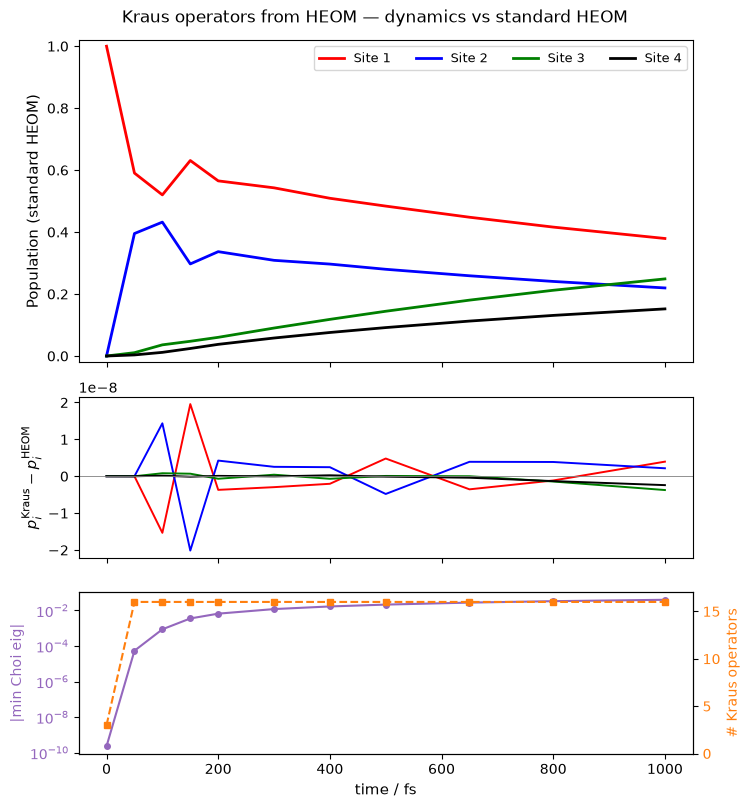

wrote heom_map_result.png ; max population deviation = 2.0e-08


In [4]:
import matplotlib.pyplot as plt

colors = ['red', 'blue', 'green', 'black']
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7.6, 8.2), sharex=True,
                                     height_ratios=[2.4, 1.2, 1.2])

for i in range(4):
    ax1.plot(t_fs, pop_heom[:, i], color=colors[i], lw=2, label=f'Site {i+1}')
ax1.set_ylabel('Population (standard HEOM)', fontsize=11)
ax1.set_ylim(-0.02, 1.02); ax1.legend(fontsize=9, ncol=4, loc='upper right')

for i in range(4):
    ax2.plot(t_fs, pop_kr[:, i] - pop_heom[:, i], color=colors[i], lw=1.4,
             label=f'Site {i+1}')
ax2.axhline(0, color='gray', lw=.6)
ax2.set_ylabel(r'$p^{\rm Kraus}_i-p^{\rm HEOM}_i$', fontsize=11)
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

ax3b = ax3.twinx()
ax3.semilogy(t_fs, np.maximum(np.abs(min_eig), 1e-16), 'o-', color='tab:purple',
             ms=4, label='|min Choi eigenvalue|')
ax3.set_ylabel('|min Choi eig|', color='tab:purple', fontsize=10)
ax3.tick_params(axis='y', labelcolor='tab:purple')
ax3b.plot(t_fs, n_kraus, 's--', color='tab:orange', ms=4)
ax3b.set_ylabel('# Kraus operators', color='tab:orange', fontsize=10)
ax3b.tick_params(axis='y', labelcolor='tab:orange'); ax3b.set_ylim(0, 17)
ax3.set_xlabel('time / fs', fontsize=11)

fig.suptitle('Kraus operators from HEOM — dynamics vs standard HEOM', fontsize=12)
fig.tight_layout()
fig.savefig('heom_map_result.png', dpi=200)
plt.show()
print('wrote heom_map_result.png ; max population deviation =',
      f'{np.abs(pop_kr - pop_heom).max():.1e}')


## 6. The Kraus operators themselves

For completeness we look at the actual $M_k(t)$ at one time: their number, the trace-preservation
identity $\sum_k M_k^\dagger M_k=\mathbb 1$, and the Kraus weights (Choi eigenvalues).


In [5]:
t_show = 500.0
C = choi_from_map(L_map(t_show * FS_TO_CM), d)
evals = np.linalg.eigvalsh(0.5 * (C + C.conj().T))[::-1]
kraus, mineig = kraus_from_choi(C, d)
completeness = sum(M.conj().T @ M for M in kraus)

print(f"t = {t_show} fs : {len(kraus)} Kraus operators")
print("sum_k M_k^dag M_k = 1 ?  ||.-I||_inf =",
      np.abs(completeness - np.eye(d)).max())
print("Kraus weights (Choi eigenvalues, largest first):")
print(np.round(evals, 4))
print("\nlargest Kraus operator M_0 (|.| entries):")
print(np.round(np.abs(kraus[0]), 3))


t = 500.0 fs : 16 Kraus operators
sum_k M_k^dag M_k = 1 ?  ||.-I||_inf = 1.5040451327133497e-10
Kraus weights (Choi eigenvalues, largest first):
[0.6221 0.5941 0.5636 0.5572 0.3051 0.2879 0.2532 0.2108 0.1467 0.1186
 0.0831 0.0775 0.067  0.0668 0.0248 0.0215]

largest Kraus operator M_0 (|.| entries):
[[0.003 0.007 0.058 0.037]
 [0.006 0.013 0.108 0.068]
 [0.    0.001 0.008 0.005]
 [0.    0.    0.003 0.002]]


## 7. Discussion

* **It works, and it is CP.** The reduced HEOM map $\mathcal L(t)=[e^{\hat{\mathcal L}t}]_{\mathbf 0\mathbf 0}$
  yields a Choi matrix that is positive to $\sim\!10^{-10}$ at $t=0$ (identity) and strictly positive
  afterwards, so the Choi $\to$ Kraus step loses nothing and the operator sum $\sum_k M_k\rho M_k^\dagger$
  reproduces the **standard HEOM** dynamics to $\sim\!10^{-8}$–$10^{-9}$ (populations identical to 4 decimals).
* **The ADO subtlety, resolved.** We obtain the *full* non-Markovian dynamics not by keeping the ADOs in
  the read-out, but by **evolving** them (from zero) and reading only the zeroth ADO. Initialising the
  higher ADOs to zero is exactly the factorised initial condition $\rho_S(0)\otimes\rho_B^{\rm eq}$; the
  memory is fully accounted for through their propagation. The map built this way is the genuine reduced
  CPTP map — no information is thrown away.
* **When CP can fail.** For aggressive truncation (too few ADOs / too shallow a hierarchy, or very strong
  coupling) the finite HEOM map can pick up small negative Choi eigenvalues (ref. 4). The `minChoiEig`
  column is the built-in monitor; `kraus_from_choi` clips values below tolerance, so a mild violation just
  costs a small, quantified error. Increasing `NK`/`DEPTH` restores CP.
* **Same downstream pipeline as the path integral.** These $M_k(t)$ are drop-in for `propagate_grid` and,
  exactly as in Seneviratne et al., for the SVD + Walsh dilation onto a quantum circuit — the HEOM map and
  the path-integral map are two independent routes to the *same* $\mathcal E_{t,0}$, and indeed they agree
  (both give $\approx(0.379,0.220,0.249,0.152)$ at 1000 fs).
